In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model and data
xgb_model = joblib.load('../models/xgboost_model.pkl')
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')
feature_names = joblib.load('../data/feature_names.pkl')

# Convert to dataframe
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print(f"Model loaded ✅")
print(f"Test set: {X_test_df.shape}")
print(f"Features: {len(feature_names)}")

# Initialize SHAP explainer
print("\nInitializing SHAP explainer...")
explainer = shap.TreeExplainer(xgb_model)
print("SHAP explainer ready ✅")

Model loaded ✅
Test set: (18343, 65)
Features: 65

Initializing SHAP explainer...
SHAP explainer ready ✅


In [2]:
# Calculate SHAP values
# Using a sample of 2000 patients to keep it fast
print("Calculating SHAP values...")
print("(This will take 2-3 minutes, please wait...)")

sample_idx = np.random.choice(len(X_test_df), 2000, replace=False)
X_sample = X_test_df.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values calculated ✅")

# Save explainer and shap values
joblib.dump(explainer, '../models/shap_explainer.pkl')
np.save('../data/shap_values.npy', shap_values)
joblib.dump(X_sample, '../data/X_sample.pkl')

print("SHAP explainer saved ✅")

Calculating SHAP values...
(This will take 2-3 minutes, please wait...)
SHAP values shape: (2000, 65)
SHAP values calculated ✅
SHAP explainer saved ✅


Generating SHAP summary plot...


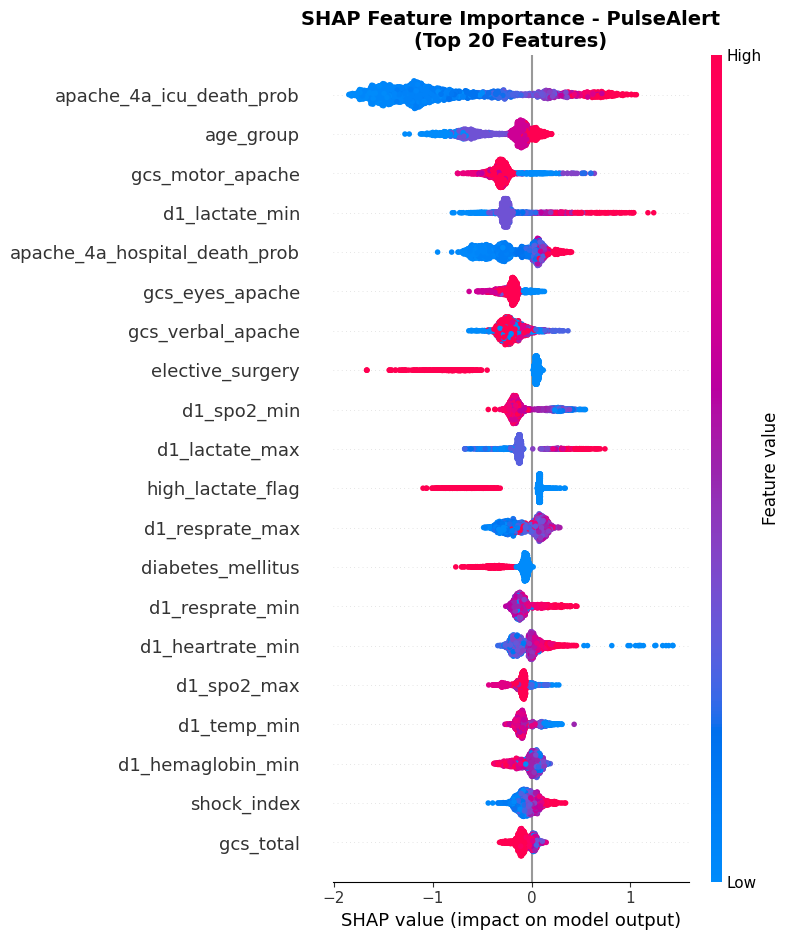

Summary plot saved ✅


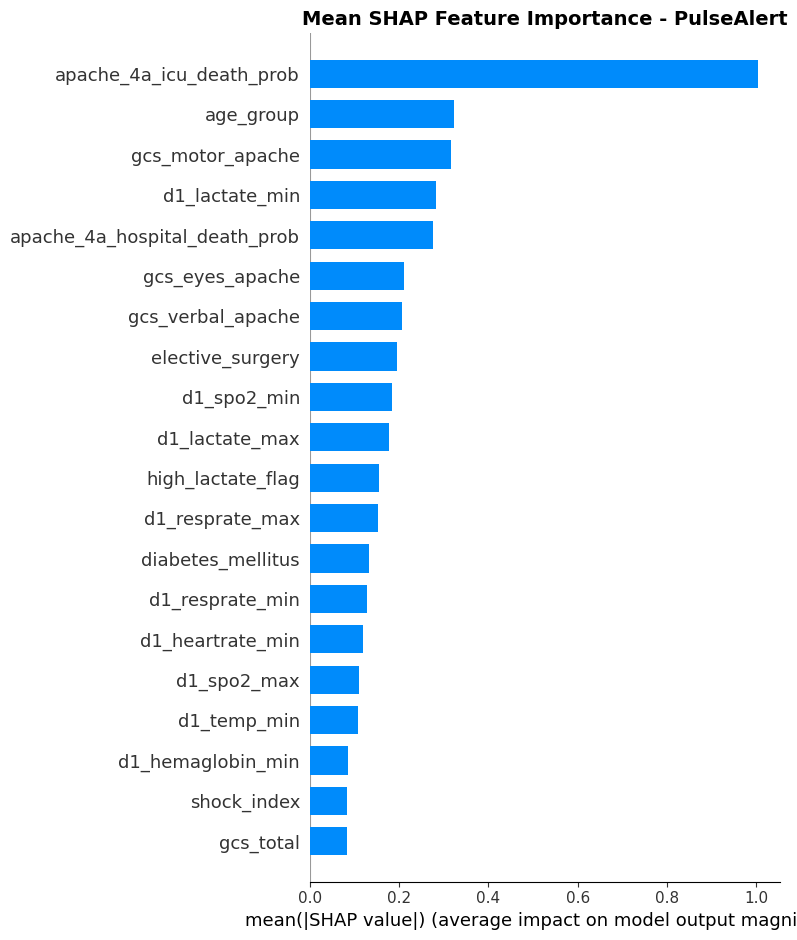

Bar plot saved ✅


In [3]:
# Plot 1 - Global Feature Importance (Summary Plot)
print("Generating SHAP summary plot...")

plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values, 
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance - PulseAlert\n(Top 20 Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved ✅")

# Plot 2 - Bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean SHAP Feature Importance - PulseAlert', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved ✅")

Finding a high risk patient from test set...
Patient index: 10
Risk score: 0.8805000185966492
Actual outcome: Survived ✅

Key vitals for this patient:
  d1_heartrate_max: 138.0
  d1_sysbp_min: 93.0
  d1_spo2_min: 78.0
  d1_resprate_max: 41.0
  d1_lactate_max: 1.9
  gcs_total: 8.0
  shock_index: 1.48
  age: 76.0
  apache_4a_icu_death_prob: 0.21


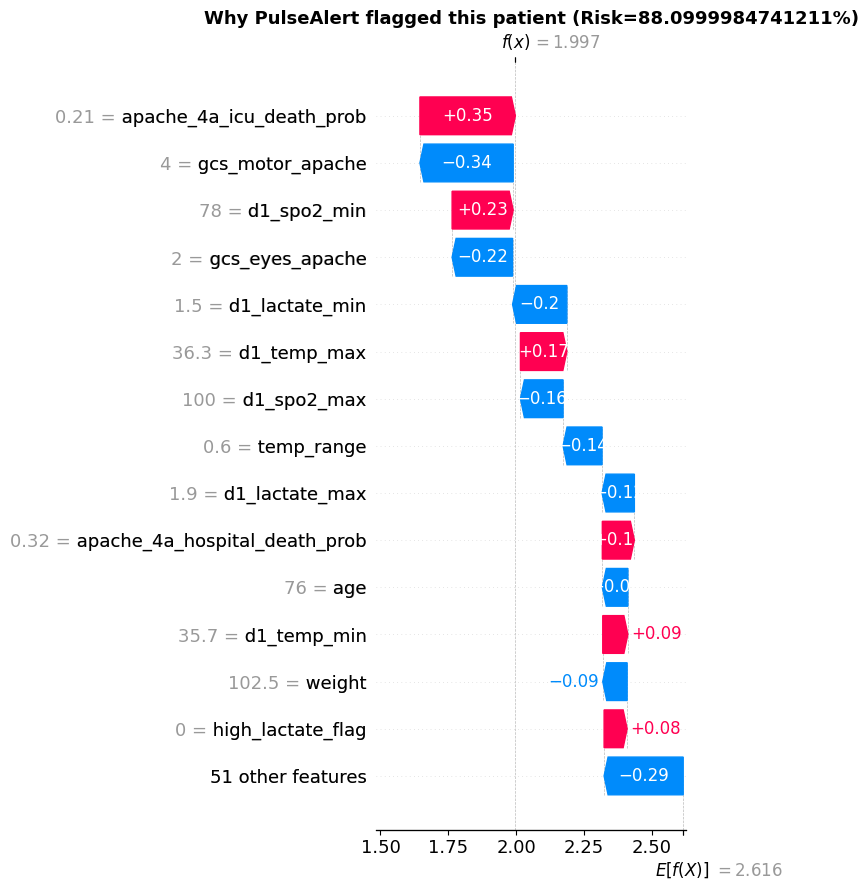

Waterfall plot saved ✅


In [4]:
# Explain a single high-risk patient
print("Finding a high risk patient from test set...")

# Get predictions
pred_probas = xgb_model.predict_proba(X_test_df)[:, 1]

# Find a high risk patient (risk > 0.8)
high_risk_idx = np.where(pred_probas > 0.8)[0][0]
high_risk_patient = X_test_df.iloc[high_risk_idx]
high_risk_proba = pred_probas[high_risk_idx]
high_risk_actual = y_test[high_risk_idx]

print(f"Patient index: {high_risk_idx}")
print(f"Risk score: {round(high_risk_proba, 4)}")
print(f"Actual outcome: {'Died ☠️' if high_risk_actual == 1 else 'Survived ✅'}")

# Show key vitals for this patient
key_vitals = [
    'd1_heartrate_max', 'd1_sysbp_min', 'd1_spo2_min',
    'd1_resprate_max', 'd1_lactate_max', 'gcs_total',
    'shock_index', 'age', 'apache_4a_icu_death_prob'
]
print(f"\nKey vitals for this patient:")
for v in key_vitals:
    print(f"  {v}: {round(high_risk_patient[v], 2)}")

# SHAP waterfall plot for this patient
shap_single = explainer(X_test_df.iloc[[high_risk_idx]])

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_single[0], max_display=15, show=False)
plt.title(f'Why PulseAlert flagged this patient (Risk={round(high_risk_proba*100,1)}%)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved ✅")

Generating force plot...


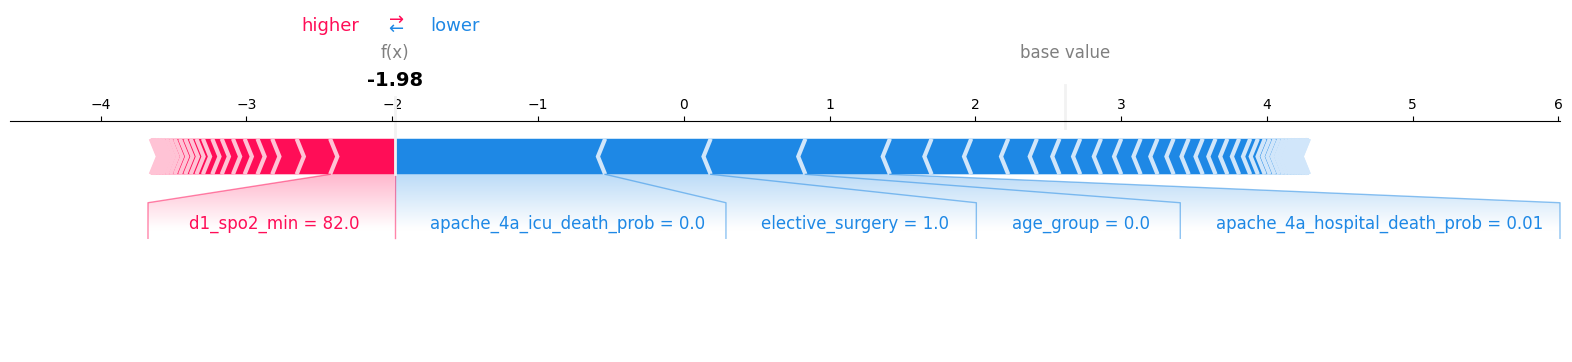

Force plot saved ✅

Notebook 05 - SHAP Explainability COMPLETE ✅

Files saved to models/:
  ✅ xgboost_model.pkl
  ✅ shap_explainer.pkl
  ✅ shap_summary.png
  ✅ shap_bar.png
  ✅ shap_waterfall.png
  ✅ shap_force.png
  ✅ optimal_threshold.pkl

All 5 notebooks COMPLETE ✅

Next step: Build FastAPI backend


In [5]:
# SHAP Force plot for same patient
print("Generating force plot...")

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.savefig('../models/shap_force.png', dpi=150, bbox_inches='tight')
plt.show()
print("Force plot saved ✅")

# Final summary
print("\n" + "="*50)
print("Notebook 05 - SHAP Explainability COMPLETE ✅")
print("="*50)
print("\nFiles saved to models/:")
print("  ✅ xgboost_model.pkl")
print("  ✅ shap_explainer.pkl")
print("  ✅ shap_summary.png")
print("  ✅ shap_bar.png")
print("  ✅ shap_waterfall.png")
print("  ✅ shap_force.png")
print("  ✅ optimal_threshold.pkl")
print("\nAll 5 notebooks COMPLETE ✅")
print("\nNext step: Build FastAPI backend")